# Separate the Training and Test Data

In [1]:
import torch
import pickle

In [2]:
from torch.utils.data import Dataset, random_split

class InstrumentDataset(Dataset):
    def __init__(self, X, y, labels):
        self.X = X
        self.y = y
        self.labels = labels

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        X_i = torch.tensor(self.X[idx].reshape((1, self.X.shape[1], self.X.shape[2])), dtype=torch.float32)
        y_i = torch.tensor(self.y[idx], dtype=torch.long)
        return X_i, y_i

data = pickle.load(open('processed_data.pkl', 'rb'))
X = data["X"]
y = data["y"]
labels_map = data["labels_map"]

generator = torch.Generator().manual_seed(42)
dataset = InstrumentDataset(X=X, y=y, labels=labels_map.keys())    

num_training_points = round(0.8*y.shape[0])
num_validation_points = round(0.2*y.shape[0])
training_dataset, validation_dataset = random_split(dataset, lengths=[num_training_points, num_validation_points], generator=generator)

In [3]:
from torch.utils.data import DataLoader
batch_size = 64
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)

In [4]:
for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print(y)

Shape of X [N, C, H, W]: torch.Size([64, 1, 20, 20])
Shape of y: torch.Size([64]) torch.int64
tensor([ 2,  0, 12,  7,  7,  3,  7,  9,  7,  6,  3,  0,  1,  4, 13,  7,  0,  0,
         7,  4,  2, 10,  7,  3,  7,  2,  9,  7,  9,  2,  3,  9,  6,  7,  0,  7,
        10,  8,  3,  1,  7,  2, 11, 11,  0, 10, 11,  0, 11,  5,  7,  3,  0, 13,
         8, 11,  3,  2,  9,  0,  3,  7,  7,  7])
Shape of X [N, C, H, W]: torch.Size([64, 1, 20, 20])
Shape of y: torch.Size([64]) torch.int64
tensor([ 0,  5, 13,  7,  0, 11,  7,  4,  6, 12,  7,  7,  7,  0,  0,  9,  7,  3,
         0,  9,  3,  0,  7,  1,  5,  0, 11,  1,  9,  2,  6,  0,  7,  7,  2,  0,
        12,  7,  7,  4, 13, 10,  3,  0,  9, 12,  8,  7,  7,  7, 12,  2,  9,  7,
         3,  0,  5,  0,  2,  2,  6,  4,  7,  7])
Shape of X [N, C, H, W]: torch.Size([64, 1, 20, 20])
Shape of y: torch.Size([64]) torch.int64
tensor([ 4, 11,  7,  7,  6,  1,  7,  6,  7,  2,  2,  5,  7,  7,  0,  7,  4,  8,
         9,  7,  8,  7,  7, 13,  7, 11,  7,  3,  4,  7,  3, 

In [5]:
from torch import nn

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(20*20, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, len(labels_map.keys()))
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=400, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=14, bias=True)
  )
)


In [6]:
train_dataloader

In [ ]:
import matplotlib.pyplot as plt

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return 1-correct

train_error = []
test_error = []
epochs = 500
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test_error.append(test(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
loss: 26.221281  [   64/ 2330]
Test Error: 
 Accuracy: 37.7%, Avg loss: 2.141099 

Epoch 2
-------------------------------
loss: 2.050626  [   64/ 2330]
Test Error: 
 Accuracy: 34.3%, Avg loss: 1.851867 

Epoch 3
-------------------------------
loss: 1.754783  [   64/ 2330]
Test Error: 
 Accuracy: 60.9%, Avg loss: 1.237389 

Epoch 4
-------------------------------
loss: 1.336328  [   64/ 2330]
Test Error: 
 Accuracy: 59.7%, Avg loss: 1.118473 

Epoch 5
-------------------------------
loss: 1.058761  [   64/ 2330]
Test Error: 
 Accuracy: 56.4%, Avg loss: 1.577134 

Epoch 6
-------------------------------
loss: 1.877611  [   64/ 2330]
Test Error: 
 Accuracy: 37.9%, Avg loss: 1.911361 

Epoch 7
-------------------------------
loss: 1.727051  [   64/ 2330]
Test Error: 
 Accuracy: 75.0%, Avg loss: 0.805332 

Epoch 8
-------------------------------
loss: 0.882006  [   64/ 2330]
Test Error: 
 Accuracy: 59.0%, Avg loss: 1.187582 

Epoch 9
---------------

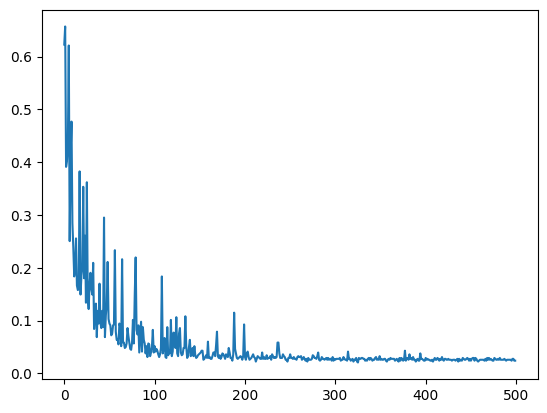

In [9]:
import numpy as np
plt.plot(1-np.array(test_error))

In [19]:
test_error

[[...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],
 [...],


Feature batch shape: torch.Size([64, 20, 20])
Labels batch shape: torch.Size([64])


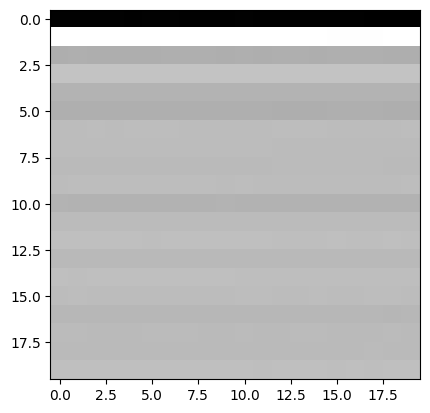

Label: 7


In [ ]:
import matplotlib.pyplot as plt
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import Dataset

class AudioDataset(DataSet):
    pass

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.module(x)
    
model = MLP()

learning_rate = 1e-3
batch_size = 64
epochs = 5

# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

100.0%
100.0%
100.0%
100.0%


Epoch 1
-------------------------------


NameError: name 'train_loop' is not defined

I got the dataset from kaggle [here](https://www.kaggle.com/datasets/thedevastator/tinysol-isolated-musical-notes-from-14-musical-i).

I decided to reduce the dimensionality of the model for our use case

https://reference.wolfram.com/language/ref/netencoder/Audio.html

Using the tutorial above, I settled on using the AudioMFCC encoder, which has a corresponding function in a Python library

https://docs.pytorch.org/audio/master/generated/torchaudio.transforms.MFCC.html



I couldn't get torchaudio working, so intead I am using a different library
[text](https://python-speech-features.readthedocs.io/en/latest/#)

Here is a pytorch version of dropout
[link](https://codesignal.com/learn/courses/improving-neural-networks-with-pytorch/lessons/adding-dropout-to-neural-networks-in-pytorch)

MLP(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: MLP(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


Layer: model.0.weight | Size: torch.Size([64, 20]) | Values : tensor([[ 0.0126, -0.1078, -0.0890,  0.1678,  0.1257, -0.0297,  0.2149, -0.0610,
         -0.1940,  0.0477, -0.1768, -0.1568, -0.2199,  0.1461,  0.1200,  0.0082,
         -0.1796, -0.1734, -0.0240,  0.1752],
        [ 0.0129, -0.0490,  0.1014, -0.0865,  0.1638,  0.1337,  0.0939, -0.1985,
         -0.1177, -0.1013, -0.2167, -0.0435, -0.2007, -0.2117,  0.0748, -0.1581,
          0.1002, -0.0108, -0.0638, -0.1369]], grad_fn=<SliceBackward0>) 

Layer: model.0.bias | Size: torch.Size([64]) | Values : tensor([-0.0620, -0.0626], grad_fn=<SliceBackward0>) 

Layer: model.3.weight | Size: torch.Size([1, 64]) | Values : tensor([[ 0.0569, -0.0402,  0.0645,  0.0838,  0.0086,  0.0886,  0.1201,  0.

In [ ]:
from python_speech_features import mfcc
from python_speech_features import logfbank
import scipy.io.wavfile as wav

nfft = 4096

(rate,sig) = wav.read("Brass/Bass_Tuba/ordinario/BTb-ord-A1-ff-N-T19d.wav")
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")

mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3)
print(mfcc_feat[mfcc_feat.shape[0]//2,:])

nfft = 4096
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")
mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3 )
# fbank_feat = logfbank(sig,rate, nfft=nfft)

print(mfcc_feat[mfcc_feat.shape[0]//2,:])

[ 1.05232418e+01  1.50886601e+01  3.85805988e+01  1.79492429e+01
  8.52495982e+00 -1.18145777e+01 -2.21171281e+01 -2.53219275e+01
 -1.68481408e+01 -1.38413999e+01 -1.36445878e-02  1.22098067e+01
 -3.67459202e-01]
[ 1.05232418e+01  1.50886601e+01  3.85805988e+01  1.79492429e+01
  8.52495982e+00 -1.18145777e+01 -2.21171281e+01 -2.53219275e+01
 -1.68481408e+01 -1.38413999e+01 -1.36445878e-02  1.22098067e+01
 -3.67459202e-01]


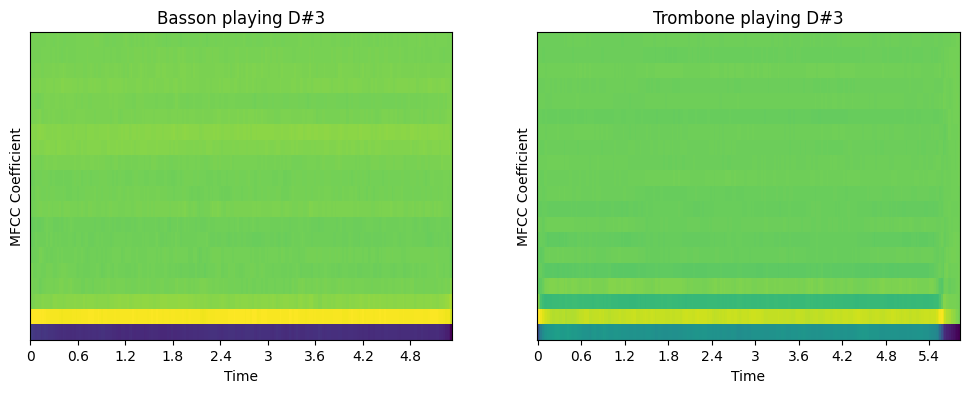

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(audio_path, ax, title):
    # Load the audio file
    y, sr = librosa.load(audio_path)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=1800)

    # Plot MFCCs
    # plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis', ax = ax)
    # ax.colorbar(format='%+2.0f dB')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('MFCC Coefficient')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Example usage
audio_file_path1 = "Winds/Bassoon/ordinario/Bn-ord-D#3-pp-N-N.wav"
# audio_file_path2 = "Brass/Bass_Tuba/ordinario/BTb-ord-D#3-mf-N-T25u.wav"
# audio_file_path1 = "Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav"
audio_file_path2 = "Brass/Trombone/ordinario/Tbn-ord-D#3-ff-N-N.wav"
# audio_file_path1 = "Strings/Viola/ordinario/Va-ord-A#3-ff-3c-N.wav"
# audio_file_path2 = "Strings/Viola/ordinario/Va-ord-G5-ff-3c-N.wav"
plot_mfcc(audio_file_path1, ax1, "Basson playing D#3")
plot_mfcc(audio_file_path2, ax2, "Trombone playing D#3")

I found this [tutorial](https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/) helpful


In [ ]:
from sklearn.neural_network import MLPClassifier

MLPClassifier()

sklearn.neural_network._multilayer_perceptron.MLPClassifier

This [tutorial](https://www.geeksforgeeks.org/deep-learning/training-neural-networks-with-dropout-for-effective-regularization/)
 goes over training with dropout with tensorflow